# Model Performance Comparison

This notebook loads all exported evaluation metrics from trained models and compares their predictive performance. Feature importance analysis is handled in separate notebooks.

**Input:** `results/performance/*_metrics.csv`

**Visualisations:**
1. Summary table — all metrics with best values highlighted
2. ROC AUC ranking — primary metric for imbalanced classification
3. Grouped bar chart — all metrics side-by-side per model
4. Precision–Recall scatter — trade-off per model
5. F1 vs ROC AUC scatter — ranking quality vs classification quality
6. SMOTE vs Undersampling delta — effect of preprocessing strategy per model (RQ3)
7. Metric heatmap — compact overview of all models × all metrics


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.rcParams.update({
    'font.family':        'sans-serif',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'figure.dpi':         120,
})

MODEL_COLORS = {
    "Logistic Regression": "#3266ad",
    "Random Forest":        "#2a8a5e",
    "XGBoost":              "#a04e0a",
    "Decision Tree":        "#7a3090",
}
MODELS = list(MODEL_COLORS.keys())

PREDICTIONS_MAP = {
    ("Logistic Regression", "SMOTE"):         "../results/logistic_regression/logistic_regression_A_predictions.pkl",
    ("Logistic Regression", "Undersampling"): "../results/logistic_regression/logistic_regression_B_predictions.pkl",
    ("Random Forest",       "SMOTE"):         "../results/random_forest/random_forest_A_predictions.pkl",
    ("Random Forest",       "Undersampling"): "../results/random_forest/random_forest_B_predictions.pkl",
    ("XGBoost",             "SMOTE"):         "../results/xgboost/xgboost_A_predictions.pkl",
    ("XGBoost",             "Undersampling"): "../results/xgboost/xgboost_B_predictions.pkl",
    ("Decision Tree",       "SMOTE"):         "../results/decision_tree/decision_tree_A_predictions.pkl",
    ("Decision Tree",       "Undersampling"): "../results/decision_tree/decision_tree_B_predictions.pkl",
}

os.makedirs("../results/figures/performance", exist_ok=True)


## Loading Model Metrics

All metric CSV files are loaded from `results/performance/` and combined into a single DataFrame. Models are sorted by ROC AUC descending, which is the primary evaluation metric given the class imbalance in the dataset.


In [2]:
metric_files = glob.glob("../results/**/*_metrics.csv")

if not metric_files:
    raise FileNotFoundError("No metric files found in ../results/performance/. Run all model notebooks first.")

comparison_df = pd.concat(
    [pd.read_csv(f) for f in metric_files],
    ignore_index=True
)

METRICS = ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"]

comparison_df = comparison_df[
    ["Strategy", "Model"] + METRICS
].sort_values("ROC AUC", ascending=False).reset_index(drop=True)

print(f"Loaded {len(comparison_df)} models")
comparison_df


Loaded 8 models


,Strategy,Model,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Undersampling,XGBoost,0.761346,0.428807,0.794297,0.556944,0.856537
1,Undersampling,Random Forest,0.757115,0.424584,0.805499,0.556063,0.854282
2,SMOTE,XGBoost,0.840192,0.609898,0.426680,0.502097,0.854034
3,Undersampling,Logistic Regression,0.760385,0.426092,0.774949,0.549855,0.848178
4,SMOTE,Random Forest,0.836923,0.609121,0.380855,0.468672,0.845461
5,SMOTE,Logistic Regression,0.763462,0.428324,0.754582,0.546460,0.842622
6,Undersampling,Decision Tree,0.718077,0.379362,0.774949,0.509371,0.805921
7,SMOTE,Decision Tree,0.797692,0.468582,0.531568,0.498092,0.802620


## Loading Model Predictions


In [3]:
def load_pkl(path, label=""):
    """Load a joblib pkl, returning None and printing a warning if missing."""
    if os.path.exists(path):
        return joblib.load(path)
    print(f"  [MISSING] {label}: {path}")
    return None
predictions  = {}

print("\nLoading prediction dicts...")
for (model, strategy), path in PREDICTIONS_MAP.items():
    predictions[(model, strategy)] = load_pkl(path, f"{model} / {strategy}")

print("Loaded predictions: ", sum(v is not None for v in predictions.values()),  "/", len(predictions))


Loading prediction dicts...
Loaded predictions:  8 / 8


## Helper Functions


In [4]:
def _slugify(value):
    """Convert model/strategy labels to safe file-name fragments."""
    return (
        str(value)
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )


def _extract_prediction_arrays(pred):
    """
    Extract y_true and y_pred arrays from a stored prediction dictionary.
    Supports the key names used across the model notebooks.
    """
    if pred is None:
        return None, None

    y_true = pred.get("y_test", pred.get("y_true", pred.get("actual", None)))
    y_pred = pred.get("predictions", pred.get("y_pred", pred.get("predicted", None)))

    if y_true is None or y_pred is None:
        return None, None

    return np.asarray(y_true), np.asarray(y_pred)


def plot_confusion_matrix_grid(predictions_dict, strategy, models, save_path=None):
    """
    Plot a 1×N grid of confusion matrices — one per model — for a given strategy.
    Loaded from the predictions pkl so no re-inference is needed.
    """
    fig, axes = plt.subplots(1, len(models), figsize=(4.5 * len(models), 4))
    axes = np.atleast_1d(axes)

    for ax, model in zip(axes, models):
        pred = predictions_dict.get((model, strategy))
        y_true, y_pred = _extract_prediction_arrays(pred)

        if y_true is None or y_pred is None:
            ax.text(0.5, 0.5, f"{model}\n(predictions not found)",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_title(model, fontsize=10, fontweight="bold",
                         color=MODEL_COLORS.get(model, "grey"))
            ax.axis("off")
        else:
            cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
            disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
            ax.set_title(model, fontsize=10, fontweight="bold",
                         color=MODEL_COLORS.get(model, "grey"))

    fig.suptitle(f"Confusion Matrices — {strategy}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[OK] Saved {save_path}")
    plt.show()


def plot_model_strategy_confusion_matrices(
    predictions_dict,
    model,
    strategies=("SMOTE", "Undersampling"),
    save_dir="../results/figures/performance",
):
    """
    Create one separate figure for a single model, comparing confusion matrices
    between preprocessing strategies. This is paper-friendly because every model
    can be included or excluded independently.
    """
    fig, axes = plt.subplots(1, len(strategies), figsize=(5 * len(strategies), 4.4))
    axes = np.atleast_1d(axes)

    saved_any = False

    for ax, strategy in zip(axes, strategies):
        pred = predictions_dict.get((model, strategy))
        y_true, y_pred = _extract_prediction_arrays(pred)

        if y_true is None or y_pred is None:
            ax.text(0.5, 0.5, f"{strategy}\n(predictions not found)",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_title(strategy, fontsize=11, fontweight="bold")
            ax.axis("off")
            continue

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
        ax.set_title(strategy, fontsize=11, fontweight="bold")
        saved_any = True

    fig.suptitle(
        f"{model}: Confusion Matrix Comparison — SMOTE vs Undersampling",
        fontsize=13,
        fontweight="bold",
        color=MODEL_COLORS.get(model, "black"),
    )
    plt.tight_layout()

    if save_dir and saved_any:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(
            save_dir,
            f"{_slugify(model)}_smote_vs_undersampling_confusion_matrices.png",
        )
        plt.savefig(save_path, bbox_inches="tight")
        print(f"[OK] Saved {save_path}")

    plt.show()


def build_confusion_matrix_summary(predictions_dict, models, strategies=("SMOTE", "Undersampling")):
    """
    Build a compact table with TN, FP, FN, TP for every model and strategy.
    The table is useful when reporting exact confusion matrix values in text.
    """
    rows = []

    for model in models:
        for strategy in strategies:
            pred = predictions_dict.get((model, strategy))
            y_true, y_pred = _extract_prediction_arrays(pred)

            if y_true is None or y_pred is None:
                rows.append({
                    "Model": model,
                    "Strategy": strategy,
                    "TN": np.nan,
                    "FP": np.nan,
                    "FN": np.nan,
                    "TP": np.nan,
                })
                continue

            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
            rows.append({
                "Model": model,
                "Strategy": strategy,
                "TN": int(tn),
                "FP": int(fp),
                "FN": int(fn),
                "TP": int(tp),
            })

    return pd.DataFrame(rows)



## Colour and Style Configuration

Consistent colours are assigned per model and hatch patterns per preprocessing strategy, so all charts use the same visual encoding.


In [5]:
MODEL_COLORS = {
    "Logistic Regression": "#3266ad",
    "Random Forest":        "#2a8a5e",
    "XGBoost":              "#a04e0a",
    "Decision Tree":        "#7a3090",
}

# Strategy names must match exactly what's exported in model notebooks
STRATEGY_HATCHES = {
    "SMOTE":         "",
    "Undersampling": "//",
}

comparison_df["label"] = comparison_df["Model"] + " / " + comparison_df["Strategy"]
comparison_df["color"] = comparison_df["Model"].map(MODEL_COLORS)
comparison_df["hatch"] = comparison_df["Strategy"].map(STRATEGY_HATCHES)

# Verify all models and strategies mapped correctly
unmapped = comparison_df[comparison_df["color"].isna() | comparison_df["hatch"].isna()]
if not unmapped.empty:
    print("WARNING — unmapped models/strategies:")
    print(unmapped[["Model", "Strategy"]])
else:
    print("[OK] All models and strategies mapped correctly.")


[OK] All models and strategies mapped correctly.


## 1. Summary Table

All models and metrics in one table. The best value per metric is highlighted in green. ROC AUC is the primary metric for model comparison given the class imbalance.


In [6]:
display_df = comparison_df[["Model", "Strategy"] + METRICS].copy()
display_df[METRICS] = display_df[METRICS].round(4)

def highlight_best(s):
    is_best = s == s.max()
    return ["background-color: #d4edda; font-weight: bold" if v else "" for v in is_best]

styled = (
    display_df.style
    .apply(highlight_best, subset=METRICS)
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#f0f0f0"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("padding", "6px 14px")]},
    ])
    .hide(axis="index")
)

print("=== Best score per metric ===")
for m in METRICS:
    best = comparison_df.loc[comparison_df[m].idxmax()]
    print(f"  {m:<12} {best[m]:.4f}  →  {best['Model']} ({best['Strategy']})")

display(styled)


=== Best score per metric ===
  Accuracy     0.8402  →  XGBoost (SMOTE)
  Precision    0.6099  →  XGBoost (SMOTE)
  Recall       0.8055  →  Random Forest (Undersampling)
  F1-score     0.5569  →  XGBoost (Undersampling)
  ROC AUC      0.8565  →  XGBoost (Undersampling)


Model,Strategy,Accuracy,Precision,Recall,F1-score,ROC AUC
XGBoost,Undersampling,0.761300,0.428800,0.794300,0.556900,0.856500
Random Forest,Undersampling,0.757100,0.424600,0.805500,0.556100,0.854300
XGBoost,SMOTE,0.840200,0.609900,0.426700,0.502100,0.854000
Logistic Regression,Undersampling,0.760400,0.426100,0.774900,0.549900,0.848200
Random Forest,SMOTE,0.836900,0.609100,0.380900,0.468700,0.845500
Logistic Regression,SMOTE,0.763500,0.428300,0.754600,0.546500,0.842600
Decision Tree,Undersampling,0.718100,0.379400,0.774900,0.509400,0.805900
Decision Tree,SMOTE,0.797700,0.468600,0.531600,0.498100,0.802600


## 2. Confusion Matrices — SMOTE

These plots show one confusion matrix per model for the SMOTE strategy. They are kept strategy-specific rather than mixed with undersampling.


[OK] Saved ../results/figures/performance/model_a_confusion_matrices.png


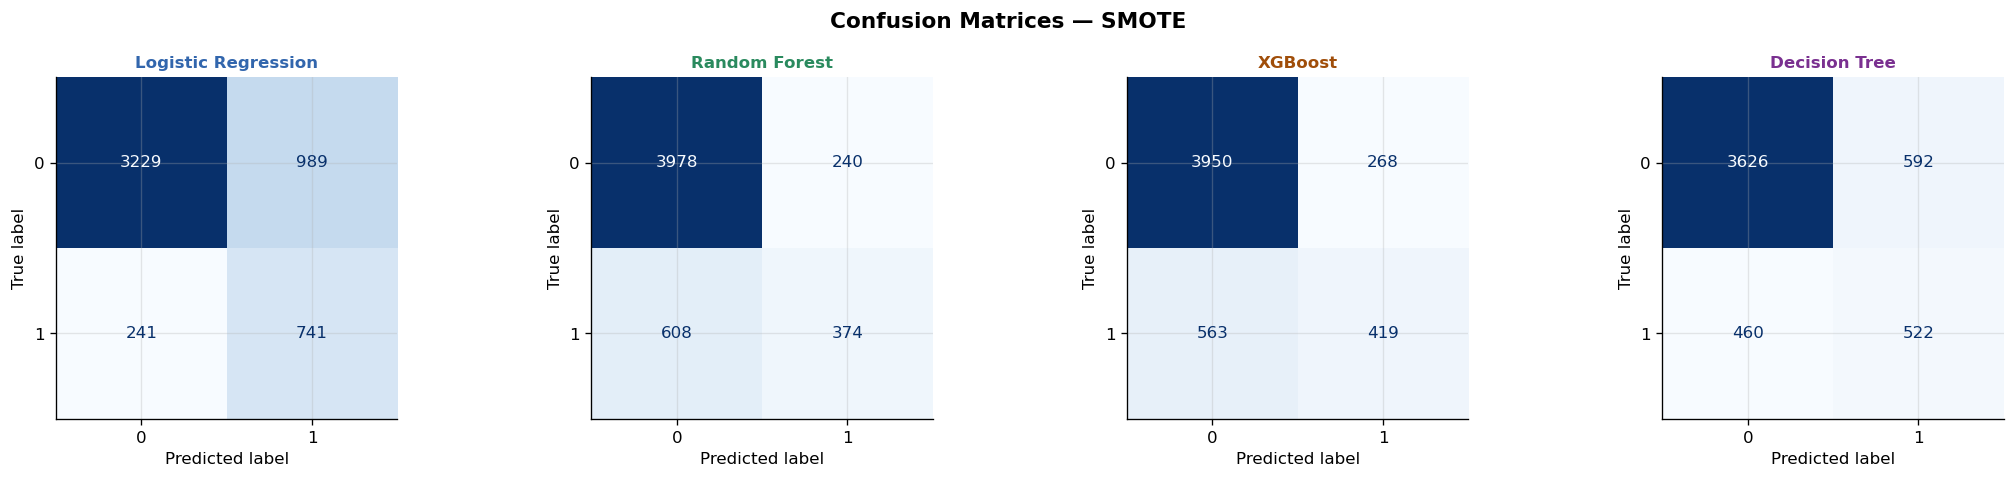

In [7]:
plot_confusion_matrix_grid(
    predictions, "SMOTE", MODELS,
    save_path="../results/figures/performance/model_a_confusion_matrices.png"
)

## 3. Confusion Matrices — Undersampling

These plots show one confusion matrix per model for the undersampling strategy. They are saved separately from the SMOTE plots.


[OK] Saved ../results/figures/performance/model_b_confusion_matrices.png


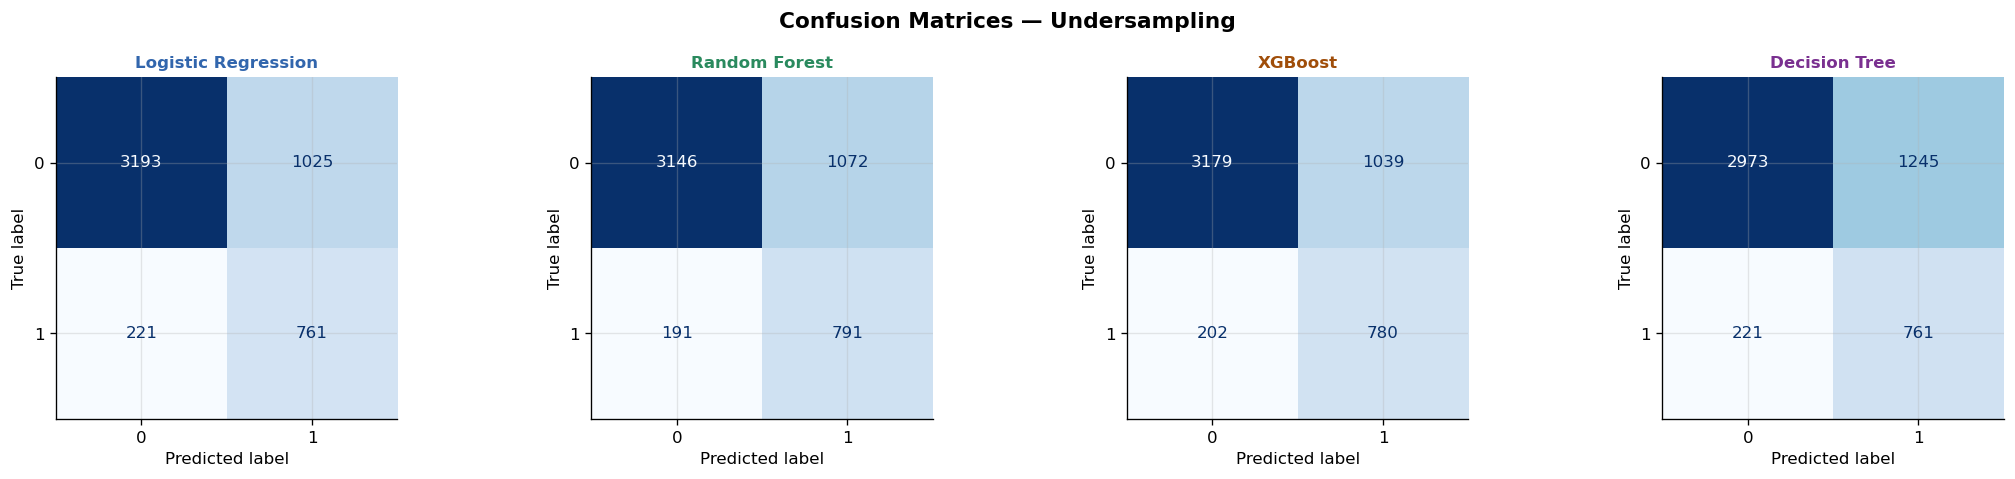

In [8]:
plot_confusion_matrix_grid(
    predictions, "Undersampling", MODELS,
    save_path="../results/figures/performance/model_b_confusion_matrices.png"
)

## 4. Model-Specific Confusion Matrix Comparisons — SMOTE vs Undersampling

Each figure compares the two preprocessing strategies for one model only, for example **XGBoost SMOTE vs XGBoost Undersampling**.


[OK] Saved ../results/figures/performance/logistic_regression_smote_vs_undersampling_confusion_matrices.png


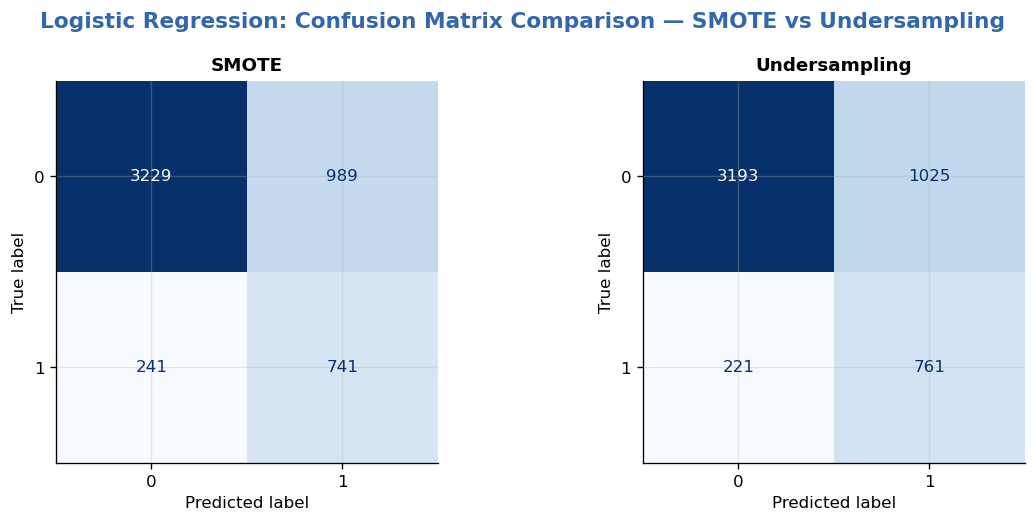

[OK] Saved ../results/figures/performance/random_forest_smote_vs_undersampling_confusion_matrices.png


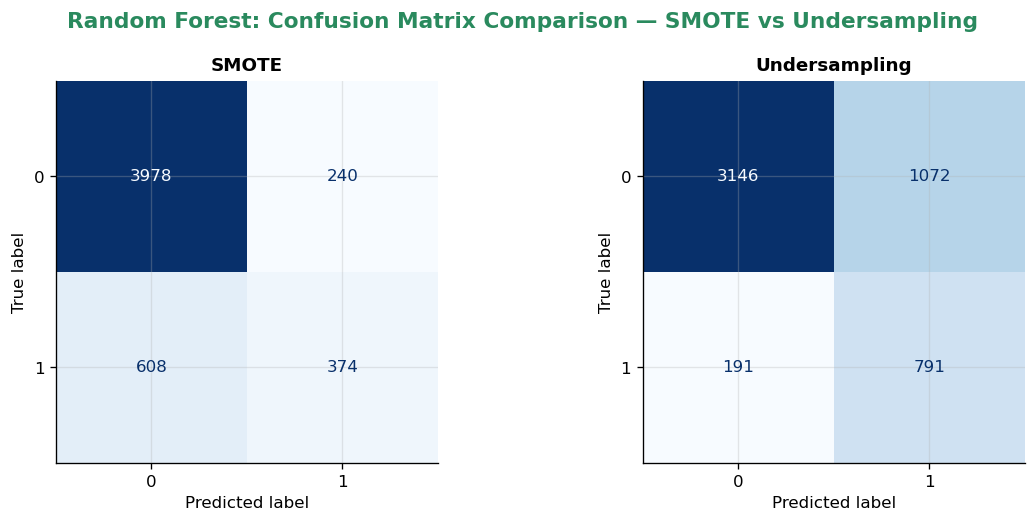

[OK] Saved ../results/figures/performance/xgboost_smote_vs_undersampling_confusion_matrices.png


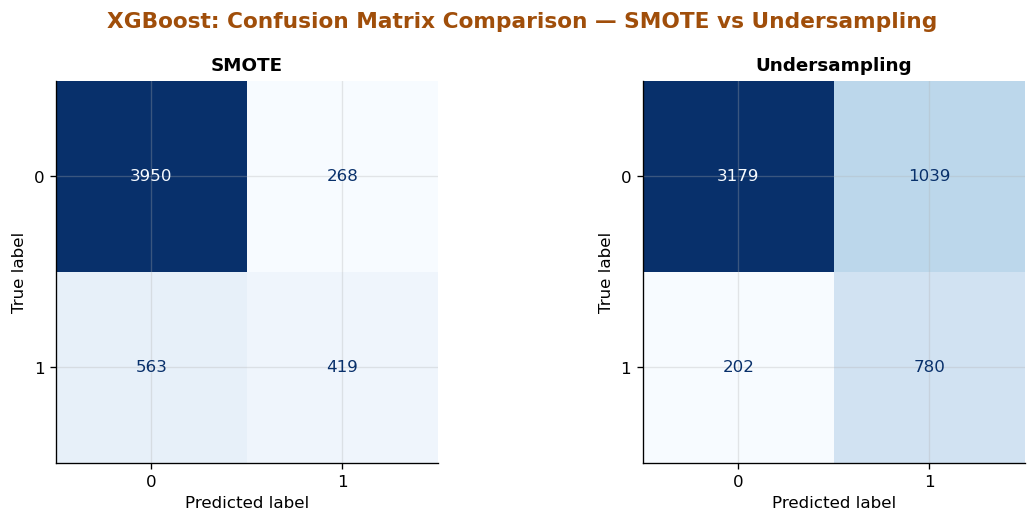

[OK] Saved ../results/figures/performance/decision_tree_smote_vs_undersampling_confusion_matrices.png


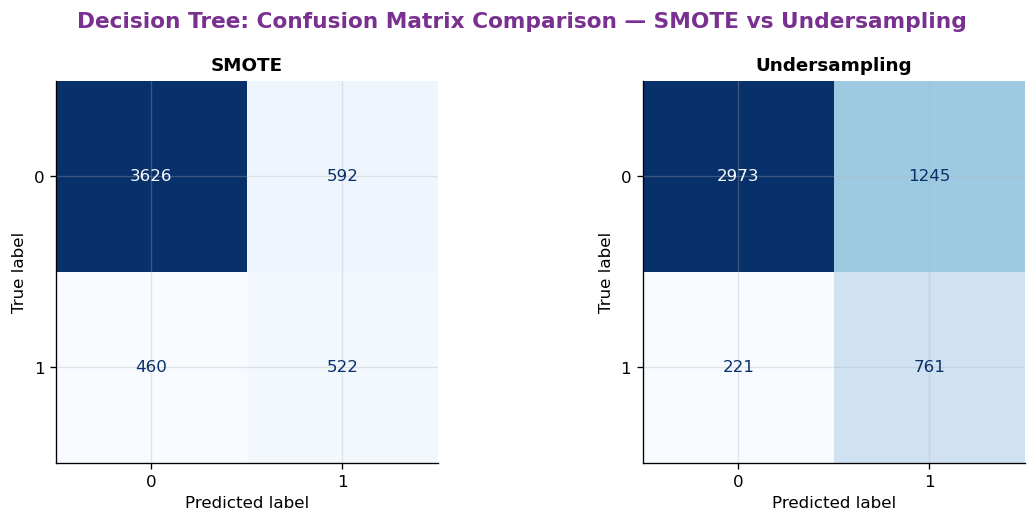

In [9]:
for model in MODELS:
    plot_model_strategy_confusion_matrices(
        predictions,
        model,
        strategies=("SMOTE", "Undersampling"),
        save_dir="../results/figures/performance",
    )


## 5. Confusion Matrix Summary Table

Exact TN, FP, FN, and TP values for every model-strategy combination. This table is also exported as a CSV file for paper reporting.


In [10]:
confusion_summary_df = build_confusion_matrix_summary(
    predictions,
    MODELS,
    strategies=("SMOTE", "Undersampling"),
)

confusion_summary_path = "../results/figures/performance/confusion_matrix_summary.csv"
confusion_summary_df.to_csv(confusion_summary_path, index=False)
print(f"[OK] Saved {confusion_summary_path}")

display(confusion_summary_df)


[OK] Saved ../results/figures/performance/confusion_matrix_summary.csv


,Model,Strategy,TN,FP,FN,TP
0,Logistic Regression,SMOTE,3229,989,241,741
1,Logistic Regression,Undersampling,3193,1025,221,761
2,Random Forest,SMOTE,3978,240,608,374
3,Random Forest,Undersampling,3146,1072,191,791
4,XGBoost,SMOTE,3950,268,563,419
5,XGBoost,Undersampling,3179,1039,202,780
6,Decision Tree,SMOTE,3626,592,460,522
7,Decision Tree,Undersampling,2973,1245,221,761


## 6. ROC AUC Ranking

ROC AUC is the primary evaluation metric because it is threshold-independent and robust to class imbalance. A score of 1.0 indicates perfect discrimination; 0.5 indicates random guessing. The dashed line marks the 0.80 target.


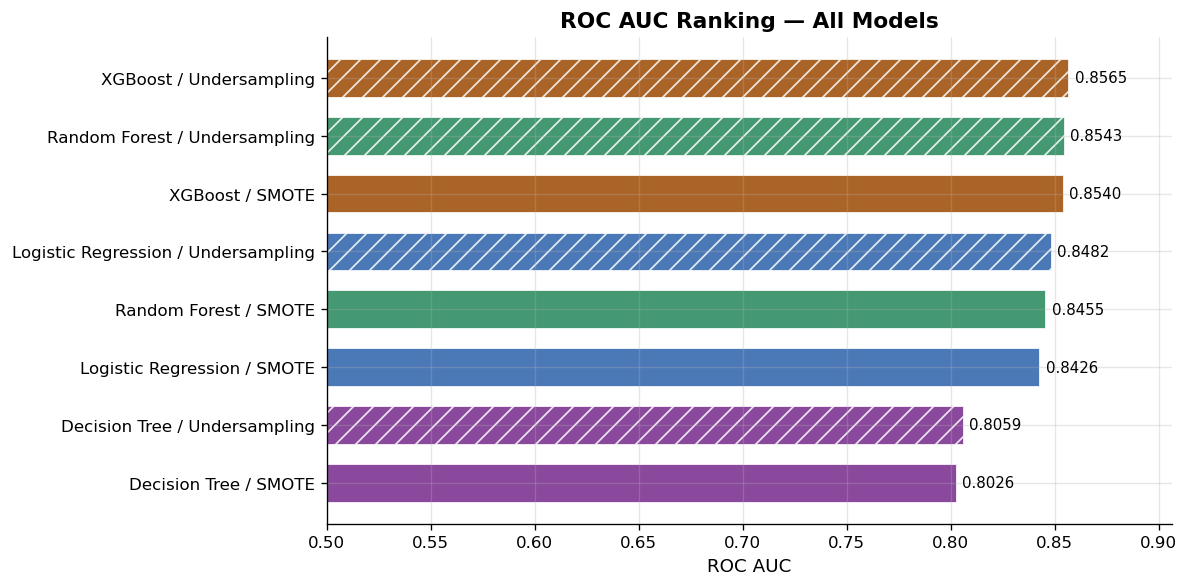

In [11]:
roc_df = comparison_df.sort_values("ROC AUC", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    roc_df["label"],
    roc_df["ROC AUC"],
    color=roc_df["color"],
    hatch=roc_df["hatch"],
    edgecolor="white",
    linewidth=0.5,
    height=0.65,
    alpha=0.88,
)

for bar, val in zip(bars, roc_df["ROC AUC"]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

ax.set_xlim(0.5, roc_df["ROC AUC"].max() + 0.05)
ax.set_xlabel("ROC AUC", fontsize=11)
ax.set_title("ROC AUC Ranking — All Models", fontsize=13, fontweight="bold")


# Legend: model colours
color_handles = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()]
strategy_handles = [
    mpatches.Patch(facecolor="white", edgecolor="gray", label="SMOTE (solid)"),
    mpatches.Patch(facecolor="white", edgecolor="gray", hatch="//", label="Undersampling (hatched)"),
]

plt.tight_layout()
plt.savefig("../results/figures/performance/comparison_roc_auc.png", bbox_inches="tight")
plt.show()


## 7. Grouped Bar Chart — All Metrics

All five metrics side-by-side for every model and strategy. Useful for spotting patterns across metrics — for example, a model with high ROC AUC but low Recall.


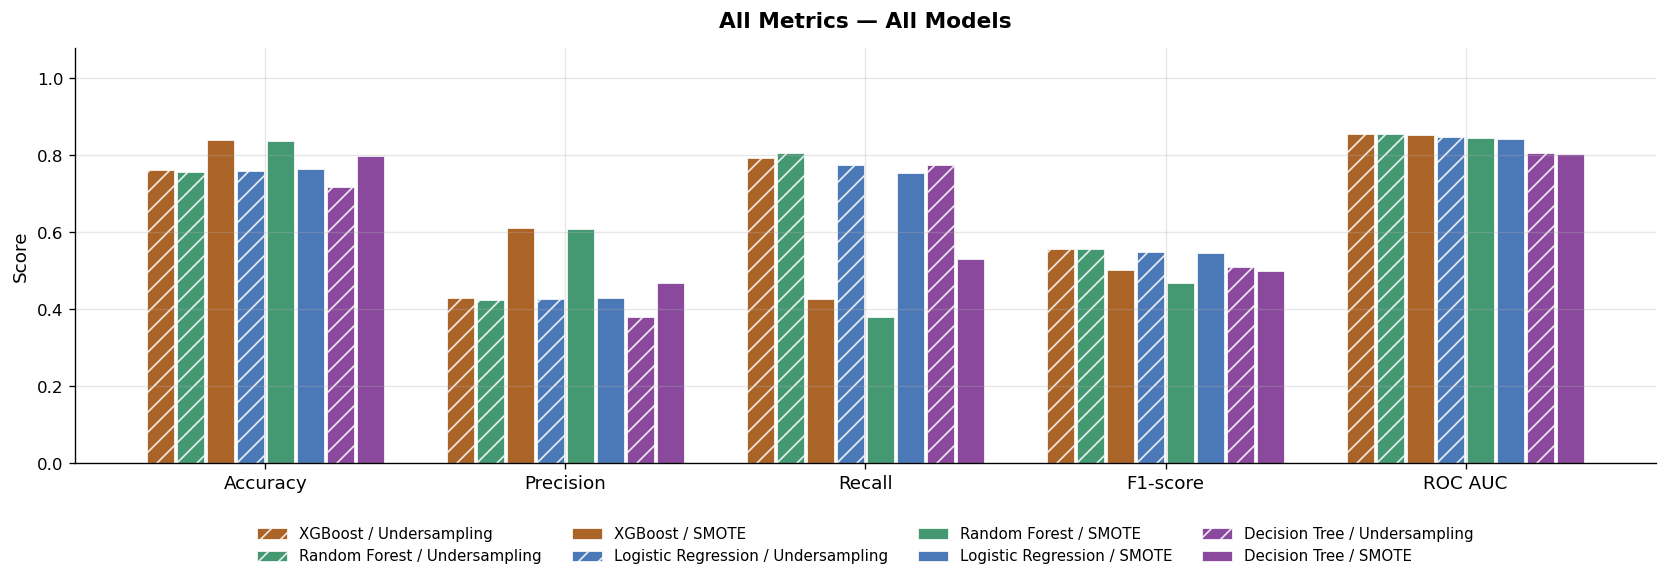

In [12]:
n_models  = len(comparison_df)
n_metrics = len(METRICS)
x     = np.arange(n_metrics)
width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(14, 5))

for i, (_, row) in enumerate(comparison_df.iterrows()):
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(
        x + offset,
        [row[m] for m in METRICS],
        width=width * 0.9,
        label=row["label"],
        color=row["color"],
        hatch=row["hatch"],
        edgecolor="white",
        linewidth=0.5,
        alpha=0.88,
    )

ax.set_xticks(x)
ax.set_xticklabels(METRICS, fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("All Metrics — All Models", fontsize=13, fontweight="bold", pad=12)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    fontsize=9,
    frameon=False,
)

plt.tight_layout()
plt.savefig("../results/figures/performance/comparison_grouped_bar.png", bbox_inches="tight")
plt.show()


## 8. Precision–Recall Scatter

Each point represents one model-strategy combination. The top-right corner is ideal (high precision and high recall simultaneously). Points closer to the top-right represent a better precision–recall trade-off. The dashed lines mark the 0.50 threshold on each axis.


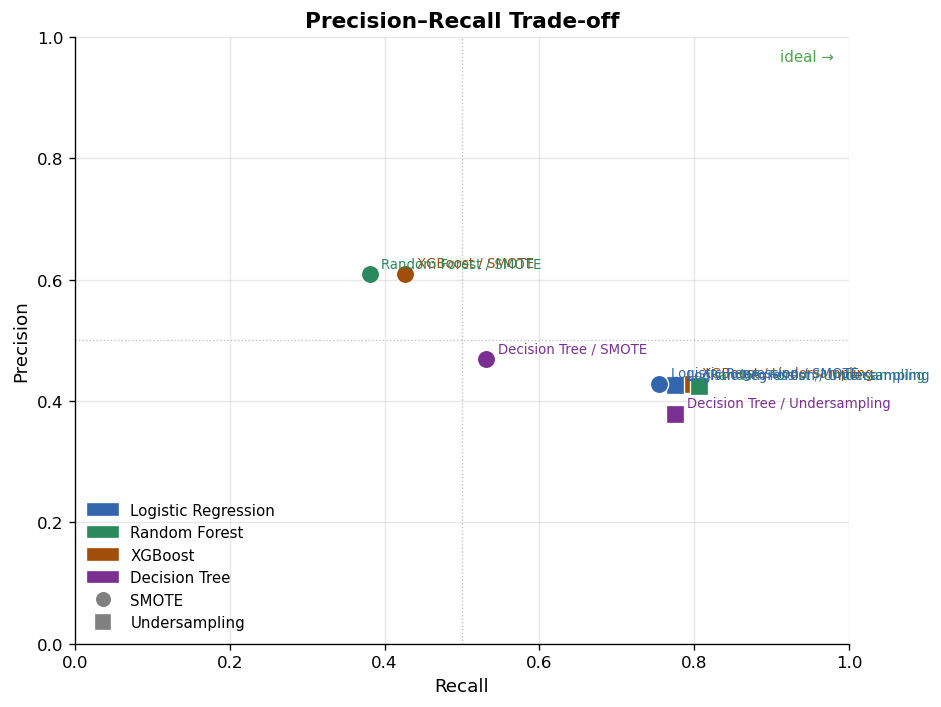

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in comparison_df.iterrows():
    marker = "o" if row["hatch"] == "" else "s"
    ax.scatter(
        row["Recall"], row["Precision"],
        color=row["color"], s=120, marker=marker,
        edgecolors="white", linewidths=0.8, zorder=3
    )
    ax.annotate(
        row["label"],
        (row["Recall"], row["Precision"]),
        textcoords="offset points",
        xytext=(7, 4),
        fontsize=8,
        color=row["color"],
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision–Recall Trade-off", fontsize=13, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
ax.axvline(0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
ax.text(0.98, 0.98, "ideal →", fontsize=9, color="green",
        ha="right", va="top", transform=ax.transAxes, alpha=0.7)

color_handles   = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()]
marker_handles  = [
    plt.Line2D([0], [0], marker="o", color="gray", linestyle="None", markersize=8, label="SMOTE"),
    plt.Line2D([0], [0], marker="s", color="gray", linestyle="None", markersize=8, label="Undersampling"),
]
ax.legend(handles=color_handles + marker_handles, fontsize=9,
          frameon=False, loc="lower left")

plt.tight_layout()
plt.savefig("../results/figures/performance/comparison_pr_scatter.png", bbox_inches="tight")
plt.show()


## 9. F1 vs ROC AUC Scatter

ROC AUC measures how well a model ranks positive cases above negative cases (threshold-independent). F1-score measures the balance between precision and recall at the default 0.5 threshold. Models in the top-right corner perform well on both dimensions. A model with high ROC AUC but low F1 suggests its probability estimates are good but the default threshold is poorly calibrated for this imbalanced dataset.


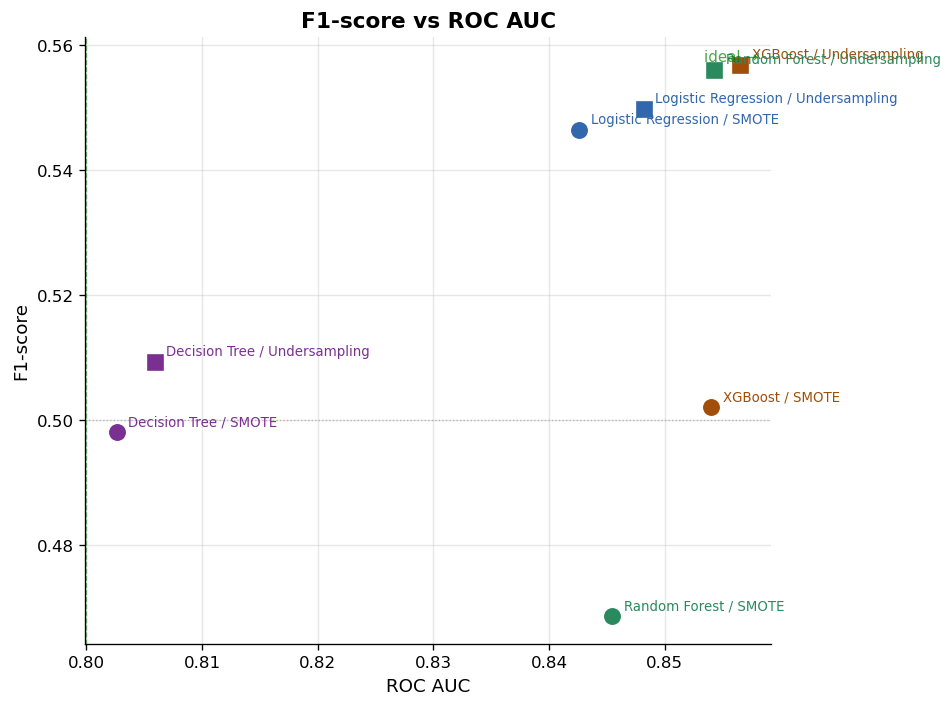

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in comparison_df.iterrows():
    marker = "o" if row["hatch"] == "" else "s"
    ax.scatter(
        row["ROC AUC"], row["F1-score"],
        color=row["color"], s=120, marker=marker,
        edgecolors="white", linewidths=0.8, zorder=3
    )
    ax.annotate(
        row["label"],
        (row["ROC AUC"], row["F1-score"]),
        textcoords="offset points",
        xytext=(7, 4),
        fontsize=8,
        color=row["color"],
    )

ax.set_xlabel("ROC AUC", fontsize=11)
ax.set_ylabel("F1-score", fontsize=11)
ax.set_title("F1-score vs ROC AUC", fontsize=13, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
ax.axvline(0.8, color="green", linestyle="--", linewidth=0.8, alpha=0.5, label="ROC AUC = 0.80")
ax.text(0.98, 0.98, "ideal →", fontsize=9, color="green",
        ha="right", va="top", transform=ax.transAxes, alpha=0.7)

color_handles  = [mpatches.Patch(color=c, label=m) for m, c in MODEL_COLORS.items()]
marker_handles = [
    plt.Line2D([0], [0], marker="o", color="gray", linestyle="None", markersize=8, label="SMOTE"),
    plt.Line2D([0], [0], marker="s", color="gray", linestyle="None", markersize=8, label="Undersampling"),
]

plt.tight_layout()
plt.savefig("../results/figures/performance/comparison_f1_vs_roc.png", bbox_inches="tight")
plt.show()


## 10. Metric Heatmap

A compact heatmap of all models × all metrics. Darker green indicates a higher score. This overview is useful for quickly identifying which models are consistently strong or weak across all metrics.


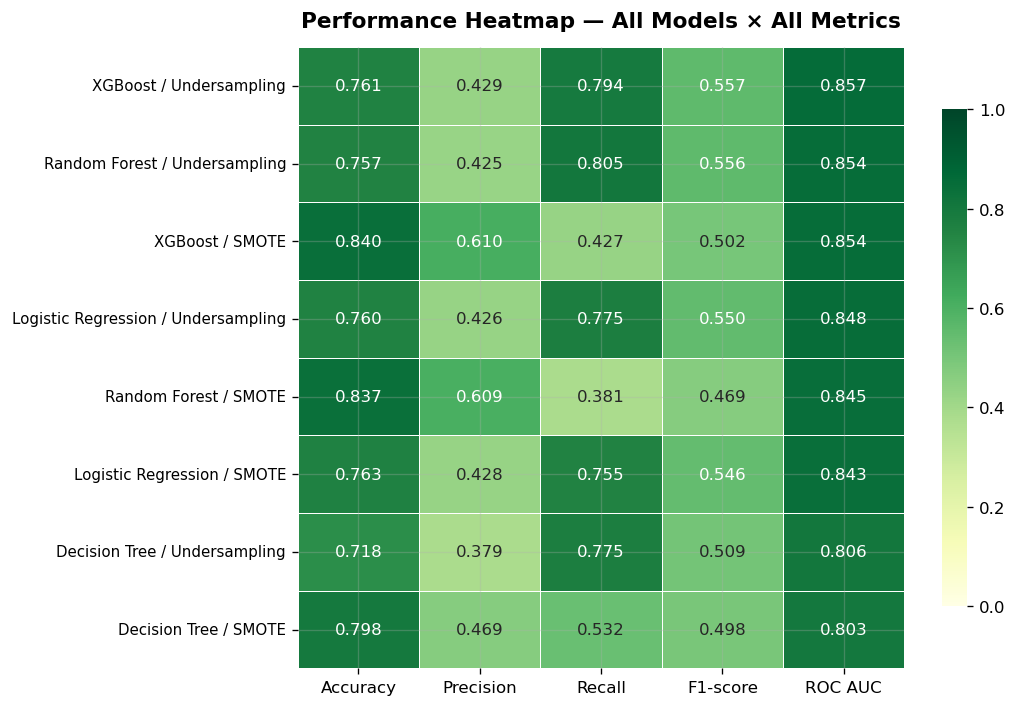

In [15]:
heatmap_data = comparison_df.set_index("label")[METRICS].astype(float)

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="YlGn",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"shrink": 0.8},
    vmin=0,
    vmax=1
)

ax.set_title("Performance Heatmap — All Models × All Metrics",fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig("../results/figures/performance/comparison_heatmap.png", bbox_inches="tight")
plt.show()
